# Generated Dialog Evaluation with Visual Frame Context

This notebook evaluates generated dialogs by incorporating visual frames from the original videos. It uses multiple evaluation strategies to assess whether dialog turns are appropriate given the visual context.

## Import Required Libraries

In [1]:
import os
import json
import re
import time
import random
from typing import List, Dict, Any, Tuple, Optional
from tqdm import tqdm
import numpy as np
from PIL import Image

# Import utilities
from mmassist.datasets.generate.openrouter_utils import OpenRouterGenerator
from mmassist.datasets.generate.frame_utils import (
    load_frames_from_arrow,
    get_frame_at_timestamp,
    image_to_base64_data_url
)

print("Libraries imported successfully!")

/u/swong2/.conda/envs/smolvlm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## Configure OpenRouter API

In [ ]:
os.environ["OPENROUTER_API_KEY"] = "your_key_here"

MODEL_CONFIGS = {
    "grok": "x-ai/grok-4-fast",
    # "claude": "anthropic/claude-sonnet-4",
    "gemini": "google/gemini-2.5-flash",
    "openai": "openai/gpt-5"
}

# Initialize evaluators
evaluators = {}
for name, model_id in MODEL_CONFIGS.items():
    try:
        evaluators[name] = OpenRouterGenerator.build(model_id=model_id)
        print(f"✓ Initialized {name} ({model_id})")
    except Exception as e:
        print(f"✗ Failed to initialize {name}: {e}")

print(f"\nInitialized {len(evaluators)} LLM evaluators")

✓ Initialized grok (x-ai/grok-4-fast)
✓ Initialized gemini (google/gemini-2.5-flash)
✓ Initialized openai (openai/gpt-5)

Initialized 3 LLM evaluators


## Load Generated Dialogs

In [10]:
DATA_ROOT_DIR = "/projects/beto/proassist_data"
DIALOG_FILE_PATH = f"{DATA_ROOT_DIR}/processed_data/egoexo4d/generated_dialogs_descriptions_keysteps_improved/train.json"

# Load generated dialogs
with open(DIALOG_FILE_PATH, "r") as f:
    generated_dialogs = json.load(f)

print(f"Loaded {len(generated_dialogs)} generated dialogs")
print(f"Sample dialog keys: {list(generated_dialogs[0].keys())}")

Loaded 1 generated dialogs
Sample dialog keys: ['video_uid', 'inferred_goal', 'inferred_knowledge', 'video_labels', 'conversations', 'parsed_video_anns', 'gen_args']


## Helper Functions

In [6]:
def extract_conversation_turns(dialog_data: Dict) -> List[Dict]:
    """Extract conversation turns with timestamps"""
    if "conversations" not in dialog_data or not dialog_data["conversations"]:
        return []
    
    conversation_turns = dialog_data["conversations"][0].get("conversation", [])
    return conversation_turns


def find_arrow_file_for_video(frames_dir: str, video_uid: str, take_name: Optional[str] = None) -> Optional[str]:
    """
    Find the Arrow file for a given video.
    
    For most datasets: looks for {video_uid}.arrow
    For EgoExo4D: looks for {take_name}_downscaled_*aria*.arrow
    
    Args:
        frames_dir: Directory containing frame Arrow files
        video_uid: The video UID
        take_name: Optional take name (for EgoExo4D dataset)
        
    Returns:
        Full path to the Arrow file if found, None otherwise
    """
    if not os.path.exists(frames_dir):
        return None
    
    # First try direct match with video_uid
    direct_file = os.path.join(frames_dir, f"{video_uid}.arrow")
    if os.path.exists(direct_file):
        return direct_file
    
    # If take_name is provided, try EgoExo4D pattern: {take_name}_downscaled_*aria*.arrow
    if take_name:
        prefix = f"{take_name}_downscaled_"
        for filename in os.listdir(frames_dir):
            if filename.startswith(prefix) and "aria" in filename and filename.endswith(".arrow"):
                return os.path.join(frames_dir, filename)
    
    return None


def sample_turns(turns: List[Dict], sample_fraction: float = 0.3) -> Tuple[List[Dict], List[Dict]]:
    """Sample user and assistant turns separately"""
    user_turns = [t for t in turns if t.get("role") == "user"]
    assistant_turns = [t for t in turns if t.get("role") == "assistant"]
    
    n_user = max(1, int(len(user_turns) * sample_fraction))
    n_assistant = max(1, int(len(assistant_turns) * sample_fraction))
    
    sampled_user = random.sample(user_turns, min(n_user, len(user_turns)))
    sampled_assistant = random.sample(assistant_turns, min(n_assistant, len(assistant_turns)))
    
    return sampled_user, sampled_assistant


def find_question_answer_pairs(turns: List[Dict]) -> List[Tuple[Dict, Dict]]:
    """Find user questions and their assistant responses"""
    qa_pairs = []
    
    for i, turn in enumerate(turns):
        if turn.get("role") == "user" and "?" in turn.get("content", ""):
            # Find the next assistant turn
            for j in range(i + 1, len(turns)):
                if turns[j].get("role") == "assistant":
                    qa_pairs.append((turn, turns[j]))
                    break
    
    return qa_pairs


def parse_scores(text: str, fields: List[str]) -> Optional[Dict[str, int]]:
    """Parse scores from LLM response"""
    if not text:
        return None
    
    # Extract JSON portion after '---' separator
    if "---" in text:
        text = text.split("---", 1)[1]
    
    text = text.strip()
    
    try:
        # Try to find JSON object
        json_match = re.search(r'\{[^}]*\}', text)
        if json_match:
            json_str = json_match.group()
            scores = json.loads(json_str)
            
            if all(field in scores and isinstance(scores[field], (int, float)) 
                   for field in fields):
                return {field: int(scores[field]) for field in fields}
    except (json.JSONDecodeError, ValueError, KeyError):
        pass
    
    # Fallback: regex extraction
    try:
        score_dict = {}
        for field in fields:
            pattern = rf'"{field}"\s*:\s*(\d+)'
            match = re.search(pattern, text, re.IGNORECASE)
            if match:
                score_dict[field] = int(match.group(1))
        
        if len(score_dict) == len(fields):
            return score_dict
    except ValueError:
        pass
    
    return None


print("Helper functions defined!")

Helper functions defined!


## Strategy 1: Visual-Turn Coherence Evaluation

Evaluate individual turns (user and assistant separately) against visual frames to check if the content makes sense given what's visible.

In [8]:
TURN_VISUAL_PROMPT = """You are evaluating a dialog turn from a cooking assistant conversation. You will see a frame from an egocentric cooking video taken at the time of the dialog turn.

Evaluate whether the dialog turn content makes sense given the visual context.

Dialog Turn (role: {role}, time: {time}s):
"{content}"

Rate the following on a scale of 1-5:
1. **Visual Relevance**: Does the turn content relate to what's visible in the frame?
2. **Contextual Appropriateness**: Is the content appropriate given the visual cooking context?
3. **Overall Coherence**: Overall, does this turn make sense with the visual frame?

Scoring:
1 = Completely irrelevant/inappropriate
2 = Mostly irrelevant
3 = Somewhat relevant
4 = Relevant and appropriate
5 = Highly relevant and appropriate

Provide brief analysis then scores as:
---
{{"visual_relevance": x, "contextual_appropriateness": y, "overall_coherence": z}}"""


def evaluate_turn_with_frame(
    turn: Dict,
    frame: Image.Image,
    evaluators: Dict[str, OpenRouterGenerator]
) -> Dict[str, Any]:
    """Evaluate a single turn against its visual frame"""
    
    # Create multimodal prompt
    frame_data_url = image_to_base64_data_url(frame)
    
    prompt_text = TURN_VISUAL_PROMPT.format(
        role=turn.get("role", "unknown"),
        time=turn.get("time", "unknown"),
        content=turn.get("content", "")
    )
    
    multimodal_content = [
        {"type": "text", "text": prompt_text},
        {"type": "image_url", "image_url": {"url": frame_data_url}}
    ]
    
    messages = [("user", multimodal_content)]
    
    # Evaluate with each model
    model_scores = {}
    for model_name, evaluator in evaluators.items():
        try:
            response = evaluator.generate(messages, temperature=0.3, max_tokens=512)
            print(response)
            scores = parse_scores(response[0], ["visual_relevance", "contextual_appropriateness", "overall_coherence"])
            model_scores[model_name] = scores
            time.sleep(1)  # Rate limiting
        except Exception as e:
            print(f"Error with {model_name}: {e}")
            model_scores[model_name] = None
    
    # Calculate average scores
    valid_scores = [s for s in model_scores.values() if s is not None]
    if valid_scores:
        avg_scores = {
            field: np.mean([s[field] for s in valid_scores])
            for field in ["visual_relevance", "contextual_appropriateness", "overall_coherence"]
        }
    else:
        avg_scores = None
    
    return {
        "turn": turn,
        "model_scores": model_scores,
        "average_scores": avg_scores
    }


print("Strategy 1 evaluation function defined!")

Strategy 1 evaluation function defined!


Running Strategy 1: Visual-Turn Coherence Evaluation
Evaluating 3 dialogs with 30% turn sampling


Dialog 1/3

Sampled 1 user + 12 assistant turns

────────────────────────────────────────────────────────────────────────────────
USER TURNS
────────────────────────────────────────────────────────────────────────────────

[User Turn 1] Time: 0.0s
Content: "I want to make milk tea from scratch."


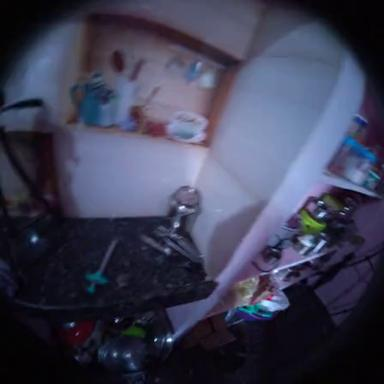

['### Analysis\nThe dialog turn initiates a cooking request for milk tea, which aligns well with the visual frame showing a typical kitchen environment (countertops, utensils, pots, sink, and various cooking tools). At 0.0s, this appears to be the start of a cooking session, making the request highly relevant and coherent in a cooking assistant context. No specific milk tea ingredients are visible yet, but the general setup supports preparing such a recipe from scratch.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The user\'s statement "I want to make milk tea from scratch" is a general request to start a cooking task. While the visual shows a kitchen environment, which is appropriate for cooking, there are no specific ingredients or tools for milk tea visible. Therefore, the statement is contextually appropriate for starting a cooking session in a kitchen, but not directly relevant to specific items in the frame.\n\n---\n{"visual_relevan

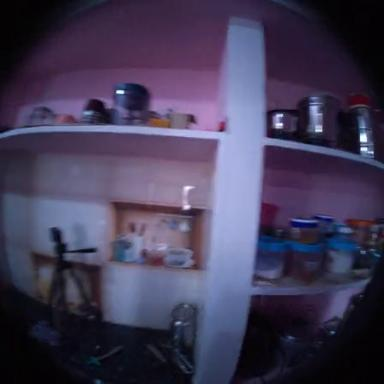

['The frame depicts a kitchen shelf stocked with various containers, jars, and utensils typical of a cooking setup, including what appear to be spice or ingredient storage jars (e.g., for sugar or similar dry goods). The assistant\'s instruction to open the sugar container is directly relevant, as it prompts interaction with visible storage items in a logical cooking progression.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}\n---']
['The image shows a kitchen shelf with various containers, some of which could contain sugar. The instruction to "Open the sugar container" is a plausible next step in a cooking process, especially if sugar is an ingredient.\n\n---\n{"visual_relevance": 4, "contextual_appropriateness": 4, "overall_coherence": 4}']
['The frame shows kitchen shelves with multiple jars/containers, fitting the idea of a sugar container being present. While we can\'t identify which one is sugar, the instruction is plausible in this cooki

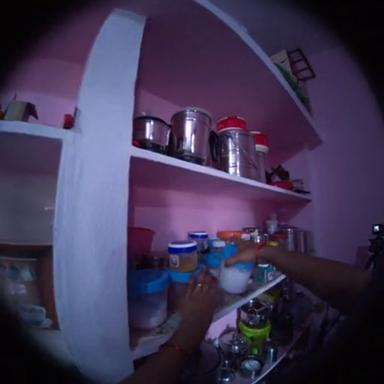

['### Analysis\nThe frame shows a kitchen shelf with various containers, including one with white granular contents (likely sugar), and hands actively handling or placing items on the shelf. The assistant\'s instruction directly addresses placing the sugar container back, which aligns with the visible action and objects, making it highly relevant in a cooking organization context.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The user\'s hands are visible in the frame, reaching towards containers on a shelf. It is plausible that one of these containers is a sugar container and the user is in the process of putting it back or taking it out. The instruction to "Place the sugar container back on the shelf" aligns with the visual of hands interacting with containers on a shelf.\n\n---\n{"visual_relevance": 4, "contextual_appropriateness": 4, "overall_coherence": 4}']
['The frame shows a person placing a small container with a white substance b

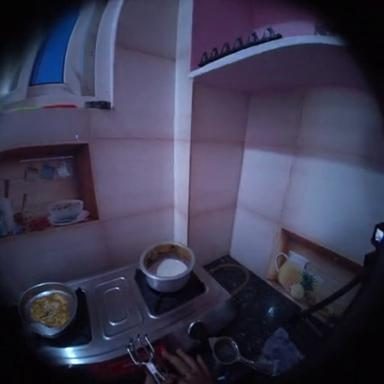

['### Analysis\nThe frame shows an egocentric view of a kitchen countertop during cooking, with visible elements including a cloth/rag (likely a napkin) on the counter, utensils like a whisk or ladle in hand (potentially tongs or similar), a stove with ongoing cooking (e.g., pan with yellow contents), and nearby bowls/jars. The instruction to pick up a napkin from the counter to clean tongs aligns well with the visible cleaning cloth and utensil handling, fitting a mid-cooking hygiene step. No major mismatches; it\'s coherent for a practical cooking assistant dialog.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The image shows a kitchen counter with cooking utensils and ingredients. The instruction to pick up a napkin and clean tongs is relevant to a cooking context, and while tongs are visible, a napkin is not explicitly seen. However, it\'s a common item to have in a kitchen.\n\n---\n{"visual_relevance": 3, "contextual_appropriateness":

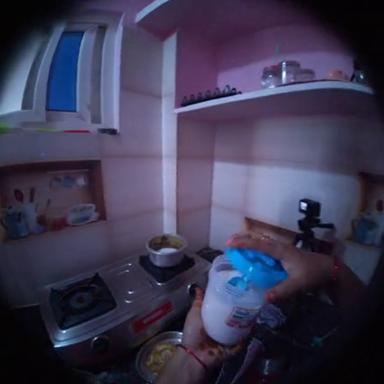

['### Analysis\nThe frame shows an egocentric view of a kitchen stove with a pan containing frying food (possibly eggs), and hands holding an open white container with a blue lid (likely sugar, given the granular white contents being poured). The dialog instructs closing the sugar container, which directly relates to the visible open container in use during cooking. This is highly relevant, as it follows a logical step after pouring ingredients, and appropriate for a safe, organized cooking process. Overall, the turn coheres well with the visual action.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The user is holding a container with a blue lid, which appears to be a sugar container. The instruction to "Close the sugar container with its lid" is directly relevant to the visual content and the action being performed or about to be performed.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The fr

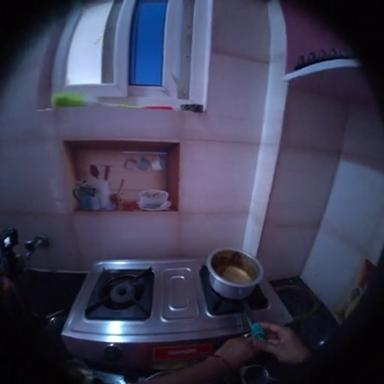

['### Analysis\nThe frame shows a gas stove with a pot containing yellowish liquid (likely oil or batter) placed on one burner, and a hand holding a green lighter near the burner knobs. This directly aligns with the assistant\'s instruction to light the stove, as the visual setup indicates preparation for igniting the gas burner to heat the pot. The content is highly relevant, appropriate for a cooking sequence, and coherent overall, suggesting the dialog turn corresponds to the exact moment of initiating cooking.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The user is holding a lighter near the stove, which has a pot on it. The assistant\'s instruction to "Light the stove with the lighter" is directly relevant to the action being performed and the objects visible in the frame.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The frame shows a gas stove with a pot and a hand holding a lighter n

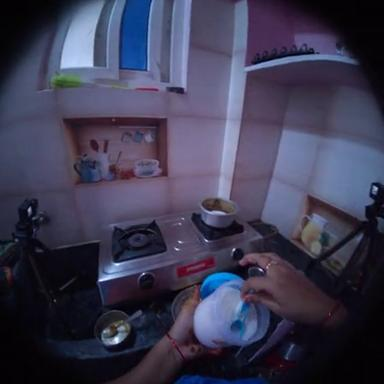

['### Analysis\nThe dialog instructs picking up a measuring spoon from a sugar container to scoop sugar, which aligns with a cooking step like adding ingredients to a mixture. The frame shows hands actively stirring a foamy mixture (likely batter or dough) in a bowl on a kitchen counter near a stove and pot, suggesting an ongoing mixing process where sugar could be a logical next addition. However, no sugar container or measuring spoon is visibly present in the frame, reducing direct visual ties, though the overall kitchen context supports ingredient handling.\n\n---\n{"visual_relevance": 3, "contextual_appropriateness": 4, "overall_coherence": 3}']
['The user is holding a container and appears to be in the process of adding ingredients. The instruction to pick up a measuring spoon from a sugar container and scoop sugar is relevant to the cooking context. While a sugar container isn\'t explicitly visible, the action of scooping ingredients is in line with what\'s happening.\n\n---\n{"v

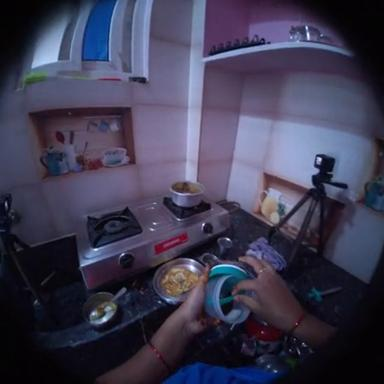

['### Brief Analysis\nThe frame shows an egocentric view of hands in a kitchen, actively scooping or pouring yellowish material (possibly tea leaves or a similar ingredient) using a green-handled utensil (likely the measuring spoon) from a container into a pan on the stove. This directly aligns with the assistant\'s instruction to pick up the measuring spoon from inside the tea leaves container, as the action appears to be in progress. The context is a cooking scenario involving measurement and ingredient handling, making it highly appropriate and coherent.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The user is holding a container and appears to be using a spoon inside it. The instruction to pick up a measuring spoon from inside a tea leaves container is highly relevant to the visual context.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The frame shows someone holding a blue-white containe

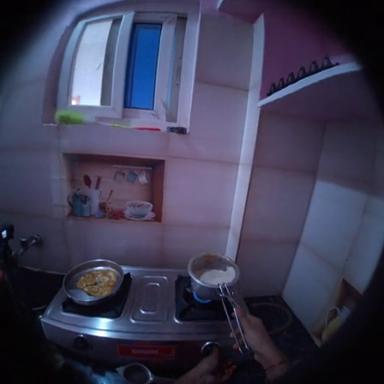

['### Analysis\nThe frame shows a close-up egocentric view of a gas stove in use, with a pan of cooked eggs on one burner and a pot of heated liquid (possibly milk) on the other, along with a visible hand interacting with the pot using tongs. The stove knobs are partially visible, indicating it\'s active. The assistant\'s instruction to turn off the stove by turning the knob directly addresses the visible cooking setup, signaling the end of a heating step, which aligns well with the context of completing food preparation (e.g., eggs and liquid are likely done). This creates high coherence, as the dialog logically follows from the observed activity without any mismatch.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The assistant\'s instruction to turn off the stove is highly relevant. The user is actively cooking on the stove, with one burner clearly lit and a pot on it. The instruction aligns perfectly with the visual context of cooking an

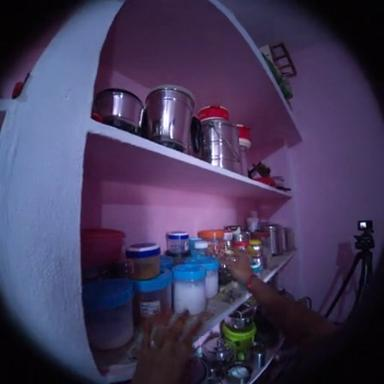

['### Analysis\nThe frame depicts an egocentric view of a kitchen shelf stocked with various containers (e.g., metal tins, plastic jars for spices/salt, colorful lids), with hands visibly reaching toward items on the shelf, suggesting an action of selecting or picking up something. The assistant\'s instruction to "pick up the tea leaves container from the shelf" directly aligns with this scene, as tea leaves would plausibly be stored in one of the visible jars or tins in a cooking context. No mismatches; it\'s coherent for a step-by-step cooking guidance, such as preparing tea.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}\n---']
['The user is reaching for something on the shelf, and the assistant\'s instruction to pick up the tea leaves container from the shelf is highly relevant and appropriate given the visual context.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The frame shows a person reach

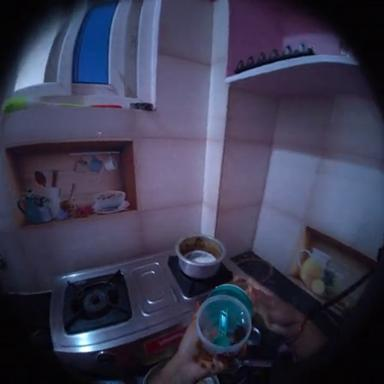

['The visual frame depicts an egocentric view of a kitchen stove with a pot containing a brown substance (possibly tea or a tea-related mixture), a hand holding a cyan object (potentially a spoon or utensil), and nearby shelves with kitchen items like cups. While a measuring spoon and tea leaves container are not explicitly visible, the hand\'s position suggests an ongoing action involving utensils, making the instruction about returning a spoon contextually tied to tea preparation. This fits a cooking assistant guiding precise steps in a recipe.\n\n---\n{"visual_relevance": 4, "contextual_appropriateness": 5, "overall_coherence": 4}\n---']
['The user is holding a container with a measuring spoon inside. The assistant\'s instruction to "Drop the measuring spoon back into the tea leaves container" is directly relevant to the visual context, as the user is holding what appears to be a container of tea leaves with a spoon.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "

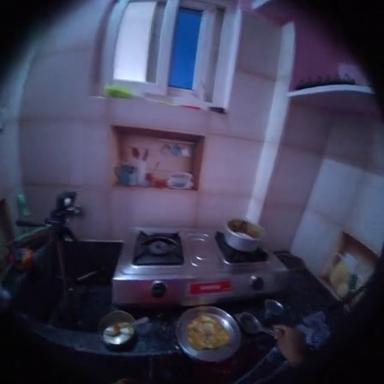

['### Analysis\nThe dialog turn instructs actions involving a tea leaves container, tea filter, and waste bag, which appear related to tea preparation or cleanup. However, the visual frame depicts an active cooking scene on a stovetop with pots containing food (e.g., a curry-like dish and another pan), utensils, shelves with generic kitchen items (jars, cups), and a hand interacting with cookware. No tea-specific items (e.g., tea leaves, filter, or waste bag) are visible, and the context suggests meal cooking rather than tea handling. This creates a mismatch, making the turn seem disconnected from the ongoing cooking activity.\n\n---\n{"visual_relevance": 2, "contextual_appropriateness": 2, "overall_coherence": 2}']
['The dialog turn mentions a "tea leaves container" and a "tea filter," but neither of these items are clearly visible or the focus of the current frame. The frame shows a kitchen scene with a stove, pots, and what appears to be food on a plate, suggesting cooking activity.

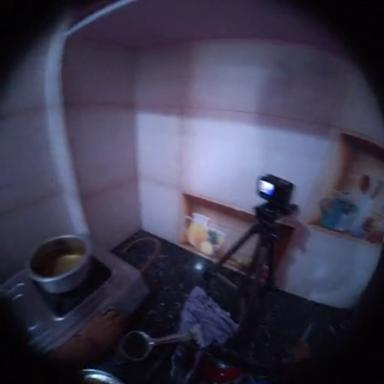

['### Analysis\nThe frame shows an egocentric view of a kitchen countertop with a stove (likely gas, given the context), a pot placed on it, utensils nearby, and general cooking setup elements like a tripod and cloths. The dialog instructs picking up a lighter (plausibly on the visible countertop) and turning the stove knob, which directly aligns with preparing to ignite the stove for cooking. This is visually relevant as the stove and countertop are prominent, contextually appropriate for an early cooking step (e.g., heating the pot), and overall coherent, though the lighter itself isn\'t explicitly detailed in the frame description.\n\n---\n{"visual_relevance": 5, "contextual_appropriateness": 5, "overall_coherence": 5}']
['The dialog turn instructs the user to pick up a lighter and turn the stove knob. The image shows a stove with a pot on it, and a hand near the stove, suggesting the user is in the process of cooking or preparing to cook. While a lighter is not explicitly visible, 

In [9]:
# Run Strategy 1 Evaluation
MAX_DIALOGS = 3  # Adjust as needed
SAMPLE_FRACTION = 0.3

strategy1_results = []

print(f"Running Strategy 1: Visual-Turn Coherence Evaluation")
print(f"Evaluating {MAX_DIALOGS} dialogs with {SAMPLE_FRACTION:.0%} turn sampling\n")

for i, dialog_data in enumerate(generated_dialogs[:MAX_DIALOGS]):
    print(f"\n{'='*80}")
    print(f"Dialog {i+1}/{MAX_DIALOGS}")
    print(f"{'='*80}")
    
    # Extract video ID
    video_uid = dialog_data.get("video_uid")
    if not video_uid:
        print(f"  No video_uid found, skipping...")
        continue
    
    # Load frames
    take_name = dialog_data["parsed_video_anns"]["take_name"]
    arrow_file = find_arrow_file_for_video("/projects/beto/proassist_data/processed_data/egoexo4d/frames/", video_uid, take_name)
    frames_data = load_frames_from_arrow(arrow_file)
    if frames_data is None:
        print(f"  Could not load frames, skipping...")
        continue
    
    # Extract turns
    turns = extract_conversation_turns(dialog_data)
    if not turns:
        print(f"  No conversation turns found, skipping...")
        continue
    
    # Sample turns
    sampled_user, sampled_assistant = sample_turns(turns, SAMPLE_FRACTION)
    print(f"\nSampled {len(sampled_user)} user + {len(sampled_assistant)} assistant turns")
    
    dialog_results = {
        "dialog_id": i,
        "video_uid": video_uid,
        "user_turn_evaluations": [],
        "assistant_turn_evaluations": []
    }
    
    # Evaluate user turns
    print(f"\n{'─'*80}")
    print("USER TURNS")
    print(f"{'─'*80}")
    for turn_idx, turn in enumerate(sampled_user, 1):
        timestamp = turn.get("time")
        if timestamp is None:
            continue
        
        frame = get_frame_at_timestamp(frames_data, timestamp)
        if frame is None:
            continue
        
        print(f"\n[User Turn {turn_idx}] Time: {timestamp}s")
        print(f"Content: \"{turn.get('content', '')}\"")
        
        # Display frame
        from IPython.display import display
        display(frame)
        
        # Evaluate
        eval_result = evaluate_turn_with_frame(turn, frame, evaluators)
        dialog_results["user_turn_evaluations"].append(eval_result)
        
        # Display model scores
        print("\nModel Evaluations:")
        for model_name, scores in eval_result["model_scores"].items():
            if scores:
                print(f"  {model_name:8s}: VR={scores['visual_relevance']}, CA={scores['contextual_appropriateness']}, OC={scores['overall_coherence']}")
            else:
                print(f"  {model_name:8s}: Failed to parse")
        
        if eval_result["average_scores"]:
            avg = eval_result["average_scores"]
            print(f"\n  Average:  VR={avg['visual_relevance']:.2f}, CA={avg['contextual_appropriateness']:.2f}, OC={avg['overall_coherence']:.2f}")
    
    # Evaluate assistant turns
    print(f"\n{'─'*80}")
    print("ASSISTANT TURNS")
    print(f"{'─'*80}")
    for turn_idx, turn in enumerate(sampled_assistant, 1):
        timestamp = turn.get("time")
        if timestamp is None:
            continue
        
        frame = get_frame_at_timestamp(frames_data, timestamp)
        if frame is None:
            continue
        
        print(f"\n[Assistant Turn {turn_idx}] Time: {timestamp}s")
        print(f"Content: \"{turn.get('content', '')}\"")
        
        # Display frame
        display(frame)
        
        # Evaluate
        eval_result = evaluate_turn_with_frame(turn, frame, evaluators)
        dialog_results["assistant_turn_evaluations"].append(eval_result)
        
        # Display model scores
        print("\nModel Evaluations:")
        for model_name, scores in eval_result["model_scores"].items():
            if scores:
                print(f"  {model_name:8s}: VR={scores['visual_relevance']}, CA={scores['contextual_appropriateness']}, OC={scores['overall_coherence']}")
            else:
                print(f"  {model_name:8s}: Failed to parse")
        
        if eval_result["average_scores"]:
            avg = eval_result["average_scores"]
            print(f"\n  Average:  VR={avg['visual_relevance']:.2f}, CA={avg['contextual_appropriateness']:.2f}, OC={avg['overall_coherence']:.2f}")
    
    strategy1_results.append(dialog_results)
    print(f"\n{'='*80}")
    print(f"Dialog {i+1} Summary: {len(dialog_results['user_turn_evaluations'])} user, "
          f"{len(dialog_results['assistant_turn_evaluations'])} assistant evaluations completed")
    print(f"{'='*80}")

print(f"\n\n🎉 Strategy 1 completed: {len(strategy1_results)} dialogs evaluated")

## Strategy 2: Question-Answer Pair Evaluation (not really visual-based eval)

Find user questions and evaluate whether the assistant's response is appropriate. 

In [16]:
QA_EVALUATION_PROMPT = """You are evaluating question-answer pairs from a cooking assistant dialog. For each pair, assess the quality of the assistant's response to the user's question.

Question-Answer Pairs:
{qa_pairs_text}

For each Q&A pair, rate on a scale of 1-5:
1. **Answer Relevance**: Does the answer directly address the question?
2. **Answer Helpfulness**: Is the answer helpful and actionable?
3. **Answer Appropriateness**: Is the answer appropriate for the cooking context?

Scoring:
1 = Very poor
2 = Poor
3 = Acceptable
4 = Good
5 = Excellent

Provide brief analysis for each pair, then scores as a JSON array:
---
[
  {{"pair_id": 1, "relevance": x, "helpfulness": y, "appropriateness": z}},
  {{"pair_id": 2, "relevance": x, "helpfulness": y, "appropriateness": z}},
  ...
]"""


def evaluate_qa_pairs(
    qa_pairs: List[Tuple[Dict, Dict]],
    evaluators: Dict[str, OpenRouterGenerator]
) -> Dict[str, Any]:
    """Evaluate all Q&A pairs in one prompt"""
    
    if not qa_pairs:
        return None
    
    # Format Q&A pairs
    qa_text_parts = []
    for idx, (q_turn, a_turn) in enumerate(qa_pairs, 1):
        q_content = q_turn.get("content", "")
        a_content = a_turn.get("content", "")
        q_time = q_turn.get("time", "unknown")
        a_time = a_turn.get("time", "unknown")
        
        qa_text_parts.append(
            f"Pair {idx}:\n"
            f"  Q (t={q_time}s): {q_content}\n"
            f"  A (t={a_time}s): {a_content}"
        )
    
    qa_pairs_text = "\n\n".join(qa_text_parts)
    
    prompt_text = QA_EVALUATION_PROMPT.format(qa_pairs_text=qa_pairs_text)
    messages = [("user", prompt_text)]
    
    # Evaluate with each model
    model_scores = {}
    for model_name, evaluator in evaluators.items():
        try:
            response = evaluator.generate(messages, temperature=0.3, max_tokens=1024)
            
            # Parse array of scores
            response_text = response[0]
            if "---" in response_text:
                response_text = response_text.split("---", 1)[1]
            
            # Extract JSON array
            json_match = re.search(r'\[.*\]', response_text, re.DOTALL)
            if json_match:
                scores_array = json.loads(json_match.group())
                model_scores[model_name] = scores_array
            else:
                model_scores[model_name] = None
            
            time.sleep(1)
        except Exception as e:
            print(f"Error with {model_name}: {e}")
            model_scores[model_name] = None
    
    # Calculate average scores per pair
    avg_scores_per_pair = []
    for pair_idx in range(len(qa_pairs)):
        pair_scores = []
        for model_name, scores_array in model_scores.items():
            if scores_array and pair_idx < len(scores_array):
                pair_scores.append(scores_array[pair_idx])
        
        if pair_scores:
            avg_scores = {
                "pair_id": pair_idx + 1,
                "relevance": np.mean([s.get("relevance", 0) for s in pair_scores if "relevance" in s]),
                "helpfulness": np.mean([s.get("helpfulness", 0) for s in pair_scores if "helpfulness" in s]),
                "appropriateness": np.mean([s.get("appropriateness", 0) for s in pair_scores if "appropriateness" in s])
            }
            avg_scores_per_pair.append(avg_scores)
    
    return {
        "model_scores": model_scores,
        "average_scores": avg_scores_per_pair
    }


print("Strategy 2 evaluation function defined!")

Strategy 2 evaluation function defined!


In [17]:
# Run Strategy 2 Evaluation
strategy2_results = []

print(f"Running Strategy 2: Question-Answer Pair Evaluation")
print(f"Evaluating {MAX_DIALOGS} dialogs\n")

for i, dialog_data in enumerate(generated_dialogs[:MAX_DIALOGS]):
    print(f"Dialog {i+1}/{MAX_DIALOGS}")
    
    video_uid = dialog_data.get("video_uid")
    turns = extract_conversation_turns(dialog_data)
    
    if not turns:
        print(f"  No conversation turns found, skipping...")
        continue
    
    # Find Q&A pairs
    qa_pairs = find_question_answer_pairs(turns)
    print(f"  Found {len(qa_pairs)} question-answer pairs")
    
    if not qa_pairs:
        print(f"  No Q&A pairs found, skipping...\n")
        continue
    
    # Evaluate all pairs together
    eval_result = evaluate_qa_pairs(qa_pairs, evaluators)
    
    strategy2_results.append({
        "dialog_id": i,
        "video_uid": video_uid,
        "num_qa_pairs": len(qa_pairs),
        "qa_pairs": qa_pairs,
        "evaluation": eval_result
    })
    
    print(f"  Completed evaluation of {len(qa_pairs)} Q&A pairs\n")

print(f"Strategy 2 completed: {len(strategy2_results)} dialogs evaluated")

Running Strategy 2: Question-Answer Pair Evaluation
Evaluating 3 dialogs

Dialog 1/3
  Found 3 question-answer pairs
  Completed evaluation of 3 Q&A pairs

Strategy 2 completed: 1 dialogs evaluated
  Completed evaluation of 3 Q&A pairs

Strategy 2 completed: 1 dialogs evaluated


## Results Summary

In [18]:
print("="*80)
print("EVALUATION RESULTS SUMMARY")
print("="*80)

# Strategy 1 Summary
print("\n📊 STRATEGY 1: Visual-Turn Coherence Evaluation")
print("-" * 60)

all_user_scores = []
all_assistant_scores = []

for result in strategy1_results:
    for eval_res in result["user_turn_evaluations"]:
        if eval_res["average_scores"]:
            all_user_scores.append(eval_res["average_scores"])
    
    for eval_res in result["assistant_turn_evaluations"]:
        if eval_res["average_scores"]:
            all_assistant_scores.append(eval_res["average_scores"])

if all_user_scores:
    print(f"\nUser Turns ({len(all_user_scores)} evaluated):")
    for field in ["visual_relevance", "contextual_appropriateness", "overall_coherence"]:
        scores = [s[field] for s in all_user_scores]
        print(f"  {field}: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

if all_assistant_scores:
    print(f"\nAssistant Turns ({len(all_assistant_scores)} evaluated):")
    for field in ["visual_relevance", "contextual_appropriateness", "overall_coherence"]:
        scores = [s[field] for s in all_assistant_scores]
        print(f"  {field}: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

# Strategy 2 Summary
print("\n\n📊 STRATEGY 2: Question-Answer Pair Evaluation")
print("-" * 60)

all_qa_scores = []
for result in strategy2_results:
    if result["evaluation"] and result["evaluation"]["average_scores"]:
        all_qa_scores.extend(result["evaluation"]["average_scores"])

if all_qa_scores:
    print(f"\nQ&A Pairs ({len(all_qa_scores)} evaluated):")
    for field in ["relevance", "helpfulness", "appropriateness"]:
        scores = [s[field] for s in all_qa_scores if field in s]
        if scores:
            print(f"  {field}: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

# Save results
timestamp = time.strftime("%Y%m%d_%H%M%S")
results_file = f"visual_dialog_evaluation_{timestamp}.json"

save_data = {
    "metadata": {
        "timestamp": timestamp,
        "num_dialogs": MAX_DIALOGS,
        "sample_fraction": SAMPLE_FRACTION,
        "models": list(evaluators.keys())
    },
    "strategy1_results": strategy1_results,
    "strategy2_results": strategy2_results
}

with open(results_file, "w") as f:
    json.dump(save_data, f, indent=2)

print(f"\n\n💾 Results saved to: {results_file}")

EVALUATION RESULTS SUMMARY

📊 STRATEGY 1: Visual-Turn Coherence Evaluation
------------------------------------------------------------

User Turns (1 evaluated):
  visual_relevance: 3.67 ± 0.00
  contextual_appropriateness: 3.00 ± 0.00
  overall_coherence: 3.33 ± 0.00

Assistant Turns (11 evaluated):
  visual_relevance: 3.44 ± 1.16
  contextual_appropriateness: 3.61 ± 0.98
  overall_coherence: 3.50 ± 1.01


📊 STRATEGY 2: Question-Answer Pair Evaluation
------------------------------------------------------------

Q&A Pairs (3 evaluated):
  relevance: 4.56 ± 0.63
  helpfulness: 3.89 ± 0.42
  appropriateness: 4.44 ± 0.57


💾 Results saved to: visual_dialog_evaluation_20251013_071155.json


## Future Evaluation Strategies

Here are additional evaluation strategies to consider for future work:

### 1. **Temporal Consistency Evaluation**
- Track key objects/ingredients mentioned across multiple turns
- Verify that visual evidence shows consistent state changes (e.g., if assistant says "the onions are now golden", check frames before and after)
- Score temporal coherence between dialog progression and visual progression

### 2. **Action-Grounding Evaluation**
- When assistant gives instructions (e.g., "stir the sauce"), check if the relevant objects are visible in nearby frames
- Evaluate whether action suggestions are grounded in visible affordances (tools, ingredients available)
- Compare frames before/after action instructions to verify feasibility

### 3. **Multi-Frame Context Evaluation**
- Instead of single frames, use sliding windows of 3-5 frames around each turn
- Evaluate whether the dialog captures the dynamics of the cooking process
- Check if assistant anticipates next steps based on visual trajectory

### 4. **Error Detection Evaluation**
- Specifically look for contradictions between visual evidence and dialog content
- Score how often the assistant makes claims not supported by frames (hallucinations)
- Evaluate the assistant's ability to correct user misconceptions based on visual evidence

### 5. **Proactive Assistance Evaluation**
- Identify moments where the assistant proactively offers help before being asked
- Check if these proactive suggestions are visually justified (e.g., warning about boiling over)
- Score the appropriateness and timeliness of proactive interventions

### 6. **Safety and Correctness Evaluation**
- Evaluate safety-related warnings (hot surfaces, sharp objects) against visual evidence
- Check cooking technique correctness (temperature, timing) when visible in frames
- Score whether the assistant catches potential safety issues visible in frames

### 7. **Cross-Modal Alignment Evaluation**
- Measure semantic similarity between frame descriptions (from vision model) and dialog content
- Evaluate whether technical cooking terms align with visual states
- Check if quantity/measurement references match visible portions

### 8. **User Intent Understanding Evaluation**
- For ambiguous user questions, evaluate if assistant's interpretation matches visual context
- Score how well the assistant disambiguates based on what's visible
- Evaluate clarifying questions against visual evidence

### 9. **Dialog Flow Quality with Visual Anchoring**
- Evaluate natural transition between topics as reflected in frame changes
- Score whether topic shifts align with visual scene changes
- Check if the assistant maintains context across different cooking stages (visible in frames)

### 10. **Comparative Evaluation with Human Annotations**
- If available, compare LLM-generated responses to human expert annotations
- Use frames to identify where LLM diverges from human judgment
- Score alignment with human-labeled key moments in the video